In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

airbnb = pd.read_csv('data/airbnb.csv')
airbnb.head(5)

,Unnamed: 0,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


In [3]:
airbnb['room_type'] = airbnb['room_type'].str.lower().str.strip()
airbnb['room_type'].unique()

<StringArray>
['private room', 'entire home/apt', 'private', 'shared room', 'home']
Length: 5, dtype: str

In [4]:
airbnb['price'] = airbnb['price'].str.strip("$").astype('float')
airbnb['price'].head()

0     45.0
1    135.0
2    150.0
3     86.0
4    160.0
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

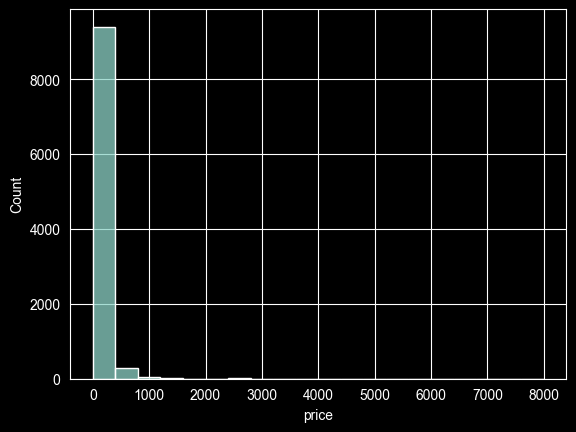

In [5]:
airbnb['price'] = airbnb['price'].astype(float)
sns.histplot(airbnb['price'], bins=20)

<Axes: xlabel='price', ylabel='Count'>

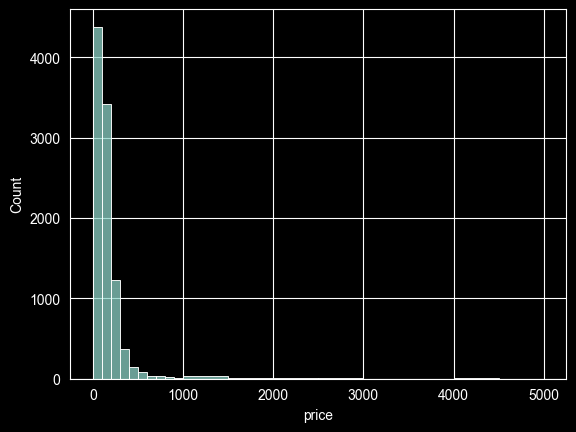

In [6]:
bins = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000]

sns.histplot(airbnb['price'], bins=bins)

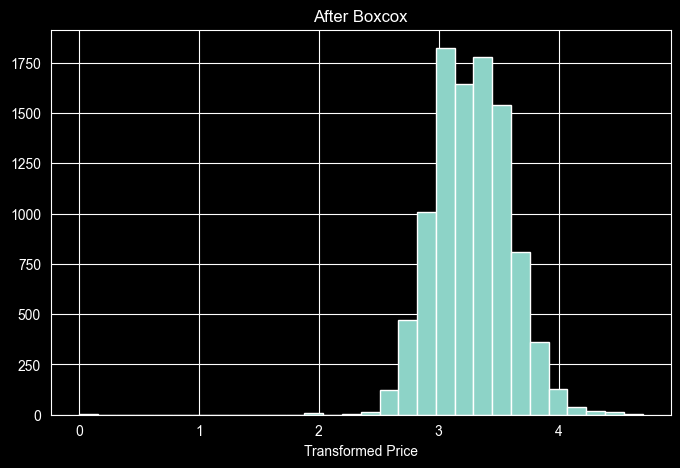

Lambda =  -0.16408279139816728


In [6]:
from scipy.stats import boxcox

price_clean = airbnb['price'].dropna()

price_boxcox, lambda_param = boxcox(price_clean + 1) # add one in case of zero values

plt.figure(figsize=(8, 5))
plt.hist(price_boxcox, bins=30)
plt.title('After Boxcox')
plt.xlabel('Transformed Price')
plt.show()
print('Lambda = ', lambda_param)

<Axes: xlabel='price'>

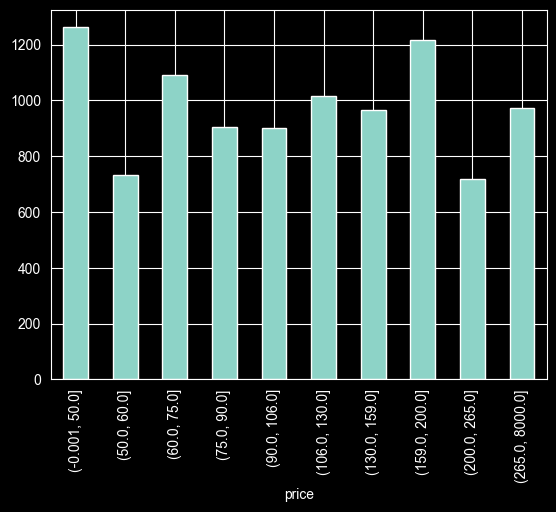

In [8]:
price_qcut = pd.qcut(airbnb['price'], q=10)
price_qcut.value_counts().sort_index().plot(kind='bar')

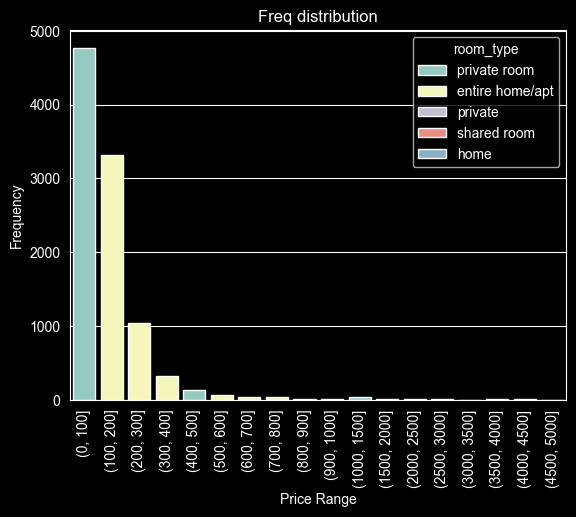

,Price Range,Frequency
0,"(0, 100]",4772
1,"(100, 200]",3316
2,"(200, 300]",1040
3,"(300, 400]",319
4,"(400, 500]",127
5,"(500, 600]",57
6,"(600, 700]",36
7,"(700, 800]",38
8,"(800, 900]",7
9,"(900, 1000]",14


In [9]:
bins = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000]

price_binned = pd.cut(airbnb['price'], bins=bins)
freq_series = price_binned.value_counts().sort_index()
freq_table = pd.DataFrame({
    'Price Range': freq_series.index.astype(str),
    'Frequency': freq_series.values
})

sns.barplot(x='Price Range', y='Frequency', data=freq_table, hue = airbnb['room_type'])
plt.xticks(rotation=90)
plt.title('Freq distribution')

plt.show()
freq_table


C:\Users\hubgo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 1.0, 'Rating against price')

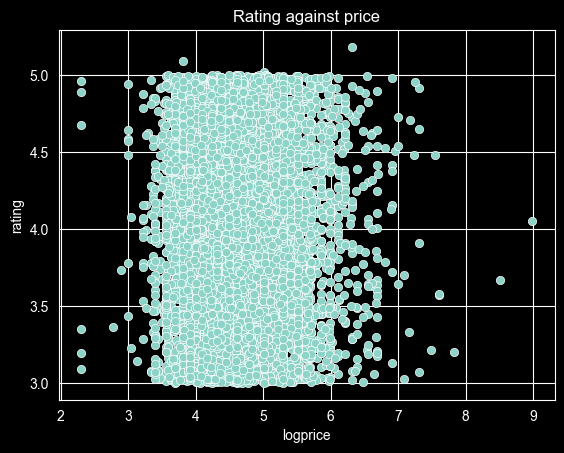

In [10]:
airbnb['logprice']=np.log(airbnb['price'])
sns.scatterplot(x='logprice', y='rating', data=airbnb)
plt.title('Rating against price')


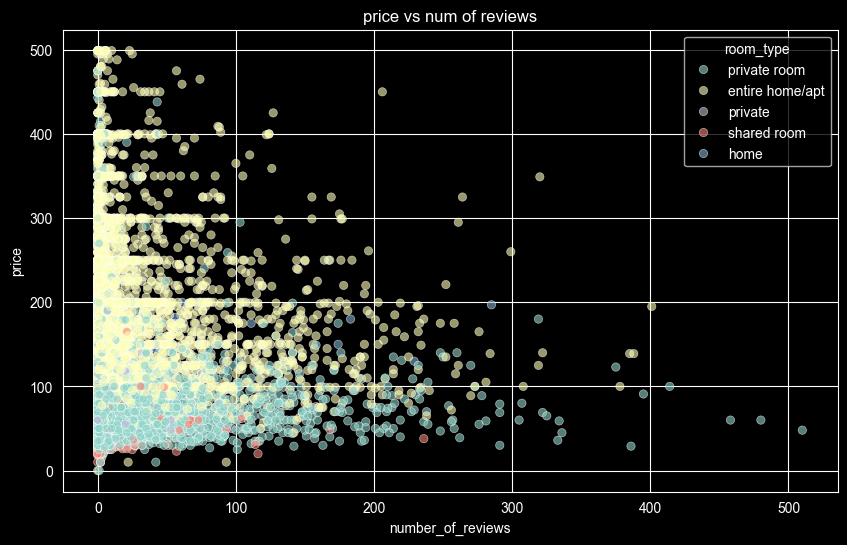

In [14]:
# only keep records with price < 500 so that outliers won't stretch the plot
airbnb_filtered = airbnb[airbnb['price'] < 500].copy()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=airbnb_filtered, x='number_of_reviews', y='price', hue='room_type', alpha=0.6)

plt.title('price vs num of reviews')
plt.xlabel('number_of_reviews')
plt.ylabel('price')

plt.show()


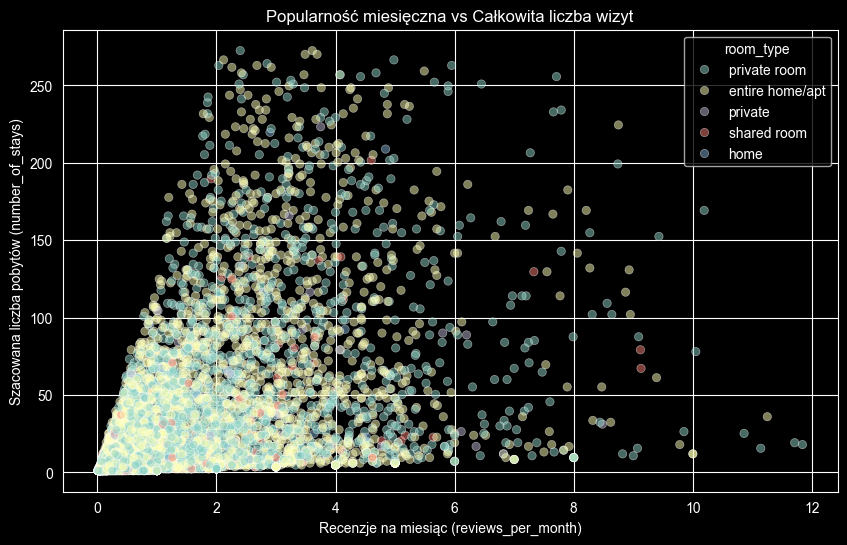

In [17]:
# NOWA ZALEŻNOŚĆ: Związek między reviews_per_month (popularnością)
# a number_of_stays (szacowaną liczbą pobytów/wizyt gości).
#
# Pytanie: Czy miejsca, które zbierają dużo recenzji w miesiącu,
# faktycznie mają najwięcej całkowitych pobytów w ciągu roku?
# Brzmi to intuicyjnie, ale rzućmy na to okiem. To powinno dać nam
# bardzo mocną, wyraźną linię na wykresie.

# Usuwamy braki danych w tych dwóch kolumnach
airbnb_stays = airbnb.dropna(subset=['reviews_per_month', 'number_of_stays']).copy()

# Odrzucamy 1% najskrajniejszych przypadków dla lepszej czytelności (np. hotele vs mieszkania)
limit_stays = airbnb_stays['number_of_stays'].quantile(0.99)
airbnb_stays_clean = airbnb_stays[airbnb_stays['number_of_stays'] < limit_stays]

# Rysujemy
plt.figure(figsize=(10, 6))

sns.scatterplot(data=airbnb_stays_clean, x='reviews_per_month', y='number_of_stays',
                hue='room_type', alpha=0.5)

plt.title('Popularność miesięczna vs Całkowita liczba wizyt')
plt.xlabel('Recenzje na miesiąc (reviews_per_month)')
plt.ylabel('Szacowana liczba pobytów (number_of_stays)')

plt.show()

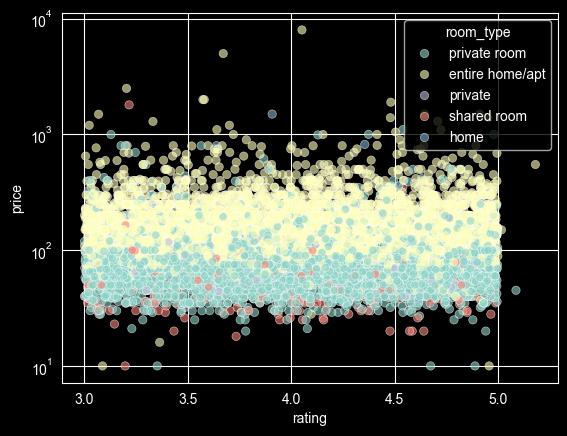

In [7]:
sns.scatterplot(data=airbnb, y='price', x='rating', hue='room_type', alpha=0.6)
plt.yscale('log')
plt.show()

<Axes: >

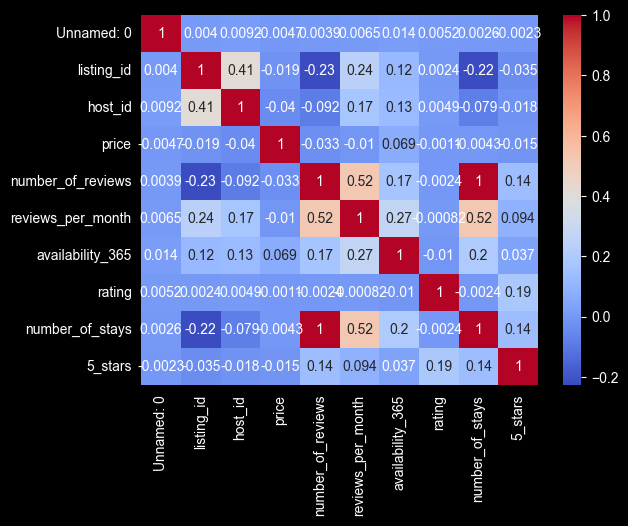

In [9]:
corr_kendall = airbnb.corr(method='kendall', numeric_only=True)
sns.heatmap(corr_kendall, annot=True, cmap='coolwarm')